In [1]:
from scACC import scACC
import numpy as np

In [2]:
X = np.concatenate([np.random.rand(500, 500), np.random.rand(500, 500) + 2])
y = np.concatenate([np.random.choice([0, 1], size=500, p=[0.05, 0.95]), 
                   np.random.choice([0, 1], size=500, p=[0.95, 0.05])])
sample_ids = np.random.choice(11, size=1000, replace=True)

<Axes: >

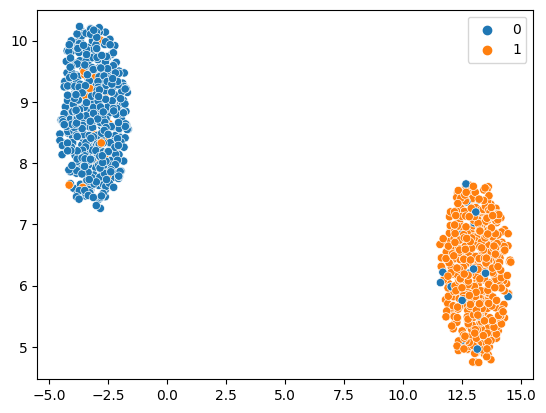

In [46]:
import umap
import seaborn as sns
umap_emb = umap.UMAP().fit_transform(X)
sns.scatterplot(x=umap_emb[:,0], y=umap_emb[:,1], hue=y)

In [4]:
model = scACC()
model.train(X_train=X, y_train=y, batch_size=256)

In [49]:
model = scACC(latent_dim=3, 
              n_clusters=30, 
              lambda_cluster=1, 
              lambda_phenotype=1, 
              device='cuda', 
              alpha=1,
              dropout=.2)
model.train(X_train=X, 
            y_train=y, 
            epoch_pretrain=15,
            epoch_train=15,
            batch_size=256,
            lr_pretrain=1e-3,
            lr_train=1e-3,
            require_pretrain_phase=True,
            require_train_phase=True,
            evaluation=False, # evaluate on test data. must be set to True when plot_evaluation is set to True
            plot_evaluation=False, # plot metics per epoch
            id_train=None, X_test=None, y_test=None, id_test=None, # used when plot_evaluation is set to True
            fold_num=None) # print out fold num in cross validation

In [50]:
z = model.get_latent_space(X)

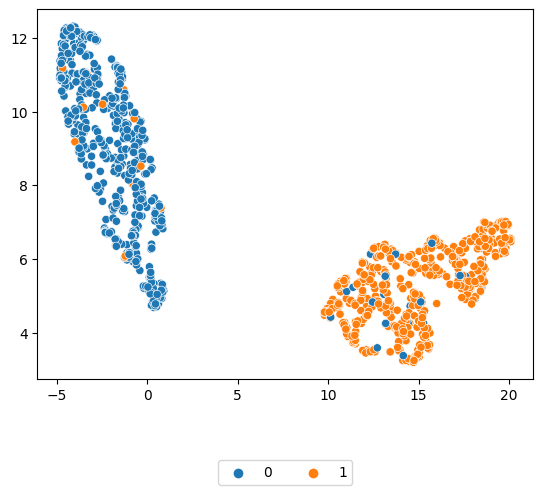

In [51]:
model.plot_latent_space(X, label=y)

In [52]:
model.get_sample_cluster_fraction_matrix(X, sample_ids=sample_ids)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
sample_ids,,,,,,,,,,,,,,,,,,,,,
0,0.049383,0.024691,0.000000,0.148148,0.000000,0.012346,0.000000,0.000000,0.049383,0.271605,...,0.012346,0.0,0.000000,0.000000,0.000000,0.000000,0.074074,0.049383,0.000000,0.000000
1,0.027397,0.000000,0.013699,0.136986,0.000000,0.000000,0.000000,0.000000,0.013699,0.301370,...,0.000000,0.0,0.027397,0.000000,0.013699,0.000000,0.109589,0.013699,0.054795,0.013699
2,0.020000,0.010000,0.000000,0.090000,0.000000,0.010000,0.000000,0.000000,0.020000,0.390000,...,0.020000,0.0,0.020000,0.000000,0.000000,0.000000,0.100000,0.010000,0.010000,0.000000
3,0.032967,0.000000,0.010989,0.065934,0.000000,0.000000,0.000000,0.000000,0.000000,0.395604,...,0.010989,0.0,0.021978,0.000000,0.021978,0.000000,0.043956,0.032967,0.000000,0.000000
4,0.022222,0.000000,0.000000,0.066667,0.000000,0.000000,0.011111,0.000000,0.055556,0.288889,...,0.011111,0.0,0.000000,0.000000,0.000000,0.011111,0.144444,0.011111,0.011111,0.000000
5,0.050000,0.000000,0.010000,0.110000,0.000000,0.000000,0.000000,0.000000,0.010000,0.380000,...,0.020000,0.0,0.040000,0.000000,0.000000,0.000000,0.020000,0.020000,0.010000,0.000000
6,0.044444,0.000000,0.000000,0.122222,0.000000,0.000000,0.000000,0.011111,0.022222,0.311111,...,0.000000,0.0,0.011111,0.000000,0.000000,0.033333,0.088889,0.011111,0.022222,0.000000
7,0.024096,0.012048,0.000000,0.060241,0.012048,0.000000,0.000000,0.000000,0.012048,0.337349,...,0.000000,0.0,0.024096,0.000000,0.000000,0.000000,0.072289,0.012048,0.024096,0.000000
8,0.035714,0.000000,0.011905,0.083333,0.000000,0.000000,0.000000,0.000000,0.011905,0.416667,...,0.011905,0.0,0.000000,0.000000,0.000000,0.000000,0.071429,0.035714,0.000000,0.011905
